# Bootstrap Analysis for Self-Prioritization Effect in Mismatch Conditions (v3)

**Updates in v3**:
1. Figure titles: "SPE calculated by strict/loose approach"
2. APA style: no grid lines, fixed axes
3. Two versions:
   - Version 1: Sample Size as is
   - Version 2: Sample Size limited to min(Shape, Label) for alignment

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set APA style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Define paths
data_path = Path("D:/GitHub_programe/GitHub/SPE_Database/1_Data")
output_path = Path("D:/GitHub_programe/GitHub/SPE_Database/3_Reports/Bootstrap")
output_path.mkdir(exist_ok=True)

# Find all Clean.csv files
clean_files = list(data_path.rglob("*_Clean.csv"))
print(f"Found {len(clean_files)} Clean.csv files")

Found 72 Clean.csv files


In [3]:
# Load and merge all Clean.csv files
all_data = []

for file_path in clean_files:
    try:
        df = pd.read_csv(file_path)
        df['Source'] = file_path.stem
        all_data.append(df)
    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")

merged_df = pd.concat(all_data, ignore_index=True)
print(f"Total merged data: {len(merged_df)} rows")

Total merged data: 1591899 rows


In [4]:
# Check columns and prepare data
print("Columns:", list(merged_df.columns))

# Check if Label_Standardized_Identity exists
has_label = 'Label_Standardized_Identity' in merged_df.columns
print(f"Has Label_Standardized_Identity: {has_label}")

if not has_label:
    print("WARNING: Using Shape for both analyses")
    merged_df['Label_Standardized_Identity'] = merged_df['Shape_Standardized_Identity']

# Filter for Nonmatching trials
mismatch_df = merged_df[merged_df['Matching'] == 'Nonmatching'].copy()
print(f"Mismatch trials: {len(mismatch_df)} rows")
print(f"Unique participants: {mismatch_df['Subject'].nunique()}")

Columns: ['Subject', 'Block', 'Trial', 'Shape', 'Label', 'Matching', 'Label_Origin_Identity', 'Label_English_Identity', 'Label_Standardized_Identity', 'Shape_Origin_Identity', 'Shape_English_Identity', 'Shape_Standardized_Identity', 'Response', 'RT_ms', 'RT_sec', 'ACC', 'Source', 'StrangerShape', 'P1Shape', 'P2Shape', 'ShapeLoc', 'Phase', 'Group', 'Condition', 'Bin', 'Morality', 'Session', 'Face', 'Stim_Type', 'Stim', 'Valence', 'Domain', 'Colour', 'ShapeColour', 'textColour', 'Stimuli_Type', 'FaceIdentity', 'Stimulus', 'Strength', 'Race', 'Speaker', 'Accent', 'Voice', 'Mood', 'Arouse', 'Unnamed: 0', 'Identity', 'Symmetry', 'Face_Gender', 'Label1', 'Label2', 'Label3']
Has Label_Standardized_Identity: True
Mismatch trials: 853015 rows
Unique participants: 1676


In [5]:
# Define helper functions
def cohens_d(group1, group2):
    """Calculate Cohen's d between two groups."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (mean1 - mean2) / pooled_sd if pooled_sd != 0 else np.nan

def filter_valid_subjects(df, identity_column):
    """Filter subjects with Self, Stranger, and at least 3 identities."""
    valid_subjects = []
    for subject, subj_df in df.groupby('Subject'):
        identities = set(subj_df[identity_column].dropna().unique())
        if 'Self' in identities and 'Stranger' in identities and len(identities) >= 3:
            valid_subjects.append(subject)
    return valid_subjects

print("Helper functions defined!")

Helper functions defined!


In [6]:
# Define data processing functions
def process_data_strict(df, analysis_type='Shape'):
    """Process data with STRICT filtering."""
    if analysis_type == 'Shape':
        identity_column = 'Shape_Standardized_Identity'
        secondary_column = 'Label_Standardized_Identity'
    else:
        identity_column = 'Label_Standardized_Identity'
        secondary_column = 'Shape_Standardized_Identity'
    
    valid_subjects = filter_valid_subjects(df, identity_column)
    df_filtered = df[df['Subject'].isin(valid_subjects)].copy()
    
    df_filtered['Primary'] = df_filtered[identity_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    df_filtered['Secondary'] = df_filtered[secondary_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    
    mask = (
        (df_filtered['Primary'] == 'Self') |
        ((df_filtered['Primary'] == 'Stranger') & (df_filtered['Secondary'] != 'Self')) |
        (df_filtered['Primary'] == 'Other')
    )
    return df_filtered[mask].copy()

def process_data_loose(df, analysis_type='Shape'):
    """Process data with LOOSE filtering."""
    identity_column = 'Shape_Standardized_Identity' if analysis_type == 'Shape' else 'Label_Standardized_Identity'
    df_filtered = df.copy()
    df_filtered['Primary'] = df_filtered[identity_column].apply(
        lambda x: x if x in ['Self', 'Stranger'] else 'Other'
    )
    return df_filtered[df_filtered['Primary'].isin(['Self', 'Stranger'])].copy()

print("Data processing functions defined!")

Data processing functions defined!


In [7]:
# Define Cohen's d calculation and bootstrap functions
def calculate_cohens_d_per_subject(df, measure='RT', min_trials=2):
    """Calculate Cohen's d for each participant."""
    results = []
    for subject, subj_df in df.groupby('Subject'):
        self_data = subj_df[subj_df['Primary'] == 'Self']
        stranger_data = subj_df[subj_df['Primary'] == 'Stranger']
        
        if measure == 'RT':
            self_values = self_data[self_data['ACC'] == 1]['RT_ms'].dropna().values
            stranger_values = stranger_data[stranger_data['ACC'] == 1]['RT_ms'].dropna().values
        else:
            self_values = self_data['ACC'].dropna().values
            stranger_values = stranger_data['ACC'].dropna().values
        
        if len(self_values) < min_trials or len(stranger_values) < min_trials:
            continue
        
        d = cohens_d(stranger_values, self_values) if measure == 'RT' else cohens_d(self_values, stranger_values)
        
        if not np.isnan(d):
            results.append({'Subject': subject, 'Cohens_d': d, 'n_self': len(self_values), 'n_stranger': len(stranger_values)})
    return pd.DataFrame(results)

def bootstrap_analysis(cohens_d_values, n_bootstrap=500, min_n=10, step=10, max_n=None):
    """Perform bootstrap resampling WITH REPLACEMENT."""
    total_n = len(cohens_d_values)
    if total_n < min_n:
        return pd.DataFrame()
    
    if max_n is None:
        max_n = total_n
    else:
        max_n = min(max_n, total_n)
    
    sample_sizes = list(range(min_n, max_n + 1, step))
    if max_n % step != 0 and max_n not in sample_sizes:
        sample_sizes.append(max_n)
    sample_sizes = sorted(set(sample_sizes))
    
    results = []
    for n in sample_sizes:
        if n > total_n:
            continue
        bootstrap_means = [np.mean(np.random.choice(cohens_d_values, size=n, replace=True)) for _ in range(n_bootstrap)]
        results.append({
            'SampleSize': n,
            'Mean_d': np.mean(bootstrap_means),
            'SE': np.std(bootstrap_means),
            'CI_lower': np.percentile(bootstrap_means, 2.5),
            'CI_upper': np.percentile(bootstrap_means, 97.5)
        })
    return pd.DataFrame(results)

print("Analysis functions defined!")

Analysis functions defined!


In [8]:
# Run STRICT filtering analysis
print("=== STRICT FILTERING ===")

# RT Analysis
rt_shape_strict = process_data_strict(mismatch_df, 'Shape')
rt_label_strict = process_data_strict(mismatch_df, 'Label')
rt_shape_cohens_strict = calculate_cohens_d_per_subject(rt_shape_strict, 'RT')
rt_label_cohens_strict = calculate_cohens_d_per_subject(rt_label_strict, 'RT')
print(f"RT - Shape: {len(rt_shape_cohens_strict)} participants, Label: {len(rt_label_cohens_strict)} participants")

# Bootstrap (original and aligned)
rt_max_n_strict = min(len(rt_shape_cohens_strict), len(rt_label_cohens_strict))
rt_shape_boot_strict = bootstrap_analysis(rt_shape_cohens_strict['Cohens_d'].values, 500)
rt_shape_boot_strict['Identity'] = 'Shape'
rt_label_boot_strict = bootstrap_analysis(rt_label_cohens_strict['Cohens_d'].values, 500)
rt_label_boot_strict['Identity'] = 'Label'
rt_shape_boot_strict_aligned = bootstrap_analysis(rt_shape_cohens_strict['Cohens_d'].values, 500, max_n=rt_max_n_strict)
rt_shape_boot_strict_aligned['Identity'] = 'Shape'
rt_label_boot_strict_aligned = bootstrap_analysis(rt_label_cohens_strict['Cohens_d'].values, 500, max_n=rt_max_n_strict)
rt_label_boot_strict_aligned['Identity'] = 'Label'

rt_boot_strict = pd.concat([rt_shape_boot_strict, rt_label_boot_strict], ignore_index=True)
rt_boot_strict_aligned = pd.concat([rt_shape_boot_strict_aligned, rt_label_boot_strict_aligned], ignore_index=True)

=== STRICT FILTERING ===
RT - Shape: 792 participants, Label: 610 participants


In [9]:
# ACC Analysis (Strict)
acc_shape_strict = process_data_strict(mismatch_df, 'Shape')
acc_label_strict = process_data_strict(mismatch_df, 'Label')
acc_shape_cohens_strict = calculate_cohens_d_per_subject(acc_shape_strict, 'ACC')
acc_label_cohens_strict = calculate_cohens_d_per_subject(acc_label_strict, 'ACC')
print(f"ACC - Shape: {len(acc_shape_cohens_strict)} participants, Label: {len(acc_label_cohens_strict)} participants")

acc_max_n_strict = min(len(acc_shape_cohens_strict), len(acc_label_cohens_strict))
acc_shape_boot_strict = bootstrap_analysis(acc_shape_cohens_strict['Cohens_d'].values, 500)
acc_shape_boot_strict['Identity'] = 'Shape'
acc_label_boot_strict = bootstrap_analysis(acc_label_cohens_strict['Cohens_d'].values, 500)
acc_label_boot_strict['Identity'] = 'Label'
acc_shape_boot_strict_aligned = bootstrap_analysis(acc_shape_cohens_strict['Cohens_d'].values, 500, max_n=acc_max_n_strict)
acc_shape_boot_strict_aligned['Identity'] = 'Shape'
acc_label_boot_strict_aligned = bootstrap_analysis(acc_label_cohens_strict['Cohens_d'].values, 500, max_n=acc_max_n_strict)
acc_label_boot_strict_aligned['Identity'] = 'Label'

acc_boot_strict = pd.concat([acc_shape_boot_strict, acc_label_boot_strict], ignore_index=True)
acc_boot_strict_aligned = pd.concat([acc_shape_boot_strict_aligned, acc_label_boot_strict_aligned], ignore_index=True)

ACC - Shape: 782 participants, Label: 590 participants


In [10]:
# Run LOOSE filtering analysis
print("=== LOOSE FILTERING ===")

rt_shape_loose = process_data_loose(mismatch_df, 'Shape')
rt_label_loose = process_data_loose(mismatch_df, 'Label')
rt_shape_cohens_loose = calculate_cohens_d_per_subject(rt_shape_loose, 'RT')
rt_label_cohens_loose = calculate_cohens_d_per_subject(rt_label_loose, 'RT')
print(f"RT - Shape: {len(rt_shape_cohens_loose)} participants, Label: {len(rt_label_cohens_loose)} participants")

rt_max_n_loose = min(len(rt_shape_cohens_loose), len(rt_label_cohens_loose))
rt_shape_boot_loose = bootstrap_analysis(rt_shape_cohens_loose['Cohens_d'].values, 500)
rt_shape_boot_loose['Identity'] = 'Shape'
rt_label_boot_loose = bootstrap_analysis(rt_label_cohens_loose['Cohens_d'].values, 500)
rt_label_boot_loose['Identity'] = 'Label'
rt_shape_boot_loose_aligned = bootstrap_analysis(rt_shape_cohens_loose['Cohens_d'].values, 500, max_n=rt_max_n_loose)
rt_shape_boot_loose_aligned['Identity'] = 'Shape'
rt_label_boot_loose_aligned = bootstrap_analysis(rt_label_cohens_loose['Cohens_d'].values, 500, max_n=rt_max_n_loose)
rt_label_boot_loose_aligned['Identity'] = 'Label'

rt_boot_loose = pd.concat([rt_shape_boot_loose, rt_label_boot_loose], ignore_index=True)
rt_boot_loose_aligned = pd.concat([rt_shape_boot_loose_aligned, rt_label_boot_loose_aligned], ignore_index=True)

=== LOOSE FILTERING ===
RT - Shape: 964 participants, Label: 813 participants


In [11]:
# ACC Analysis (Loose)
acc_shape_loose = process_data_loose(mismatch_df, 'Shape')
acc_label_loose = process_data_loose(mismatch_df, 'Label')
acc_shape_cohens_loose = calculate_cohens_d_per_subject(acc_shape_loose, 'ACC')
acc_label_cohens_loose = calculate_cohens_d_per_subject(acc_label_loose, 'ACC')
print(f"ACC - Shape: {len(acc_shape_cohens_loose)} participants, Label: {len(acc_label_cohens_loose)} participants")

acc_max_n_loose = min(len(acc_shape_cohens_loose), len(acc_label_cohens_loose))
acc_shape_boot_loose = bootstrap_analysis(acc_shape_cohens_loose['Cohens_d'].values, 500)
acc_shape_boot_loose['Identity'] = 'Shape'
acc_label_boot_loose = bootstrap_analysis(acc_label_cohens_loose['Cohens_d'].values, 500)
acc_label_boot_loose['Identity'] = 'Label'
acc_shape_boot_loose_aligned = bootstrap_analysis(acc_shape_cohens_loose['Cohens_d'].values, 500, max_n=acc_max_n_loose)
acc_shape_boot_loose_aligned['Identity'] = 'Shape'
acc_label_boot_loose_aligned = bootstrap_analysis(acc_label_cohens_loose['Cohens_d'].values, 500, max_n=acc_max_n_loose)
acc_label_boot_loose_aligned['Identity'] = 'Label'

acc_boot_loose = pd.concat([acc_shape_boot_loose, acc_label_boot_loose], ignore_index=True)
acc_boot_loose_aligned = pd.concat([acc_shape_boot_loose_aligned, acc_label_boot_loose_aligned], ignore_index=True)

ACC - Shape: 954 participants, Label: 800 participants


In [12]:
# Create APA-style figure function
def create_apa_figure(strict_rt, strict_acc, loose_rt, loose_acc, version='original'):
    """Create APA-style figure with fixed axes."""
    identity_colors = {'Shape': '#2E86AB', 'Label': '#A23B72'}
    
    # Fixed axis limits for consistency
    x_min, x_max = 0, 500
    y_min, y_max = -0.4, 0.4
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    plot_configs = [
        (axes[0, 0], strict_rt, 'RT', 'SPE calculated by strict approach'),
        (axes[0, 1], strict_acc, 'ACC', 'SPE calculated by strict approach'),
        (axes[1, 0], loose_rt, 'RT', 'SPE calculated by loose approach'),
        (axes[1, 1], loose_acc, 'ACC', 'SPE calculated by loose approach'),
    ]
    
    for ax, data, measure, title in plot_configs:
        # APA style: white background, no grid
        ax.set_facecolor('white')
        ax.grid(False)
        
        if data.empty:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes, fontsize=14)
            continue
        
        for identity in ['Shape', 'Label']:
            subset = data[data['Identity'] == identity]
            if subset.empty:
                continue
            color = identity_colors[identity]
            ax.plot(subset['SampleSize'], subset['Mean_d'], color=color, linewidth=2, label=identity)
            ax.fill_between(subset['SampleSize'], subset['CI_lower'], subset['CI_upper'], color=color, alpha=0.2)
            ax.scatter(subset['SampleSize'], subset['Mean_d'], color=color, s=20, zorder=5)
        
        # Zero line
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # Fixed axes
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        # Labels
        y_label = "Cohen's d (Stranger - Self)" if measure == 'RT' else "Cohen's d (Self - Stranger)"
        subplot_label = ('A' if 'strict' in title.lower() else 'C') if measure == 'RT' else ('B' if 'strict' in title.lower() else 'D')
        
        ax.set_xlabel('Sample Size', fontsize=12, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
        ax.set_title(f"{title}\n({measure})", fontsize=13, fontweight='bold', family='Times New Roman')
        ax.text(-0.1, 1.1, subplot_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
        ax.legend(title='Identity', fontsize=10, title_fontsize=11, loc='upper right', framealpha=0.9)
        
        # APA style: remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    filename = f'combined_figures_apa_{version}.png'
    plt.savefig(output_path / filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print(f"Saved: {filename}")

print("Figure function defined!")

Figure function defined!



=== GENERATING VERSION 1: ORIGINAL SAMPLE SIZES ===


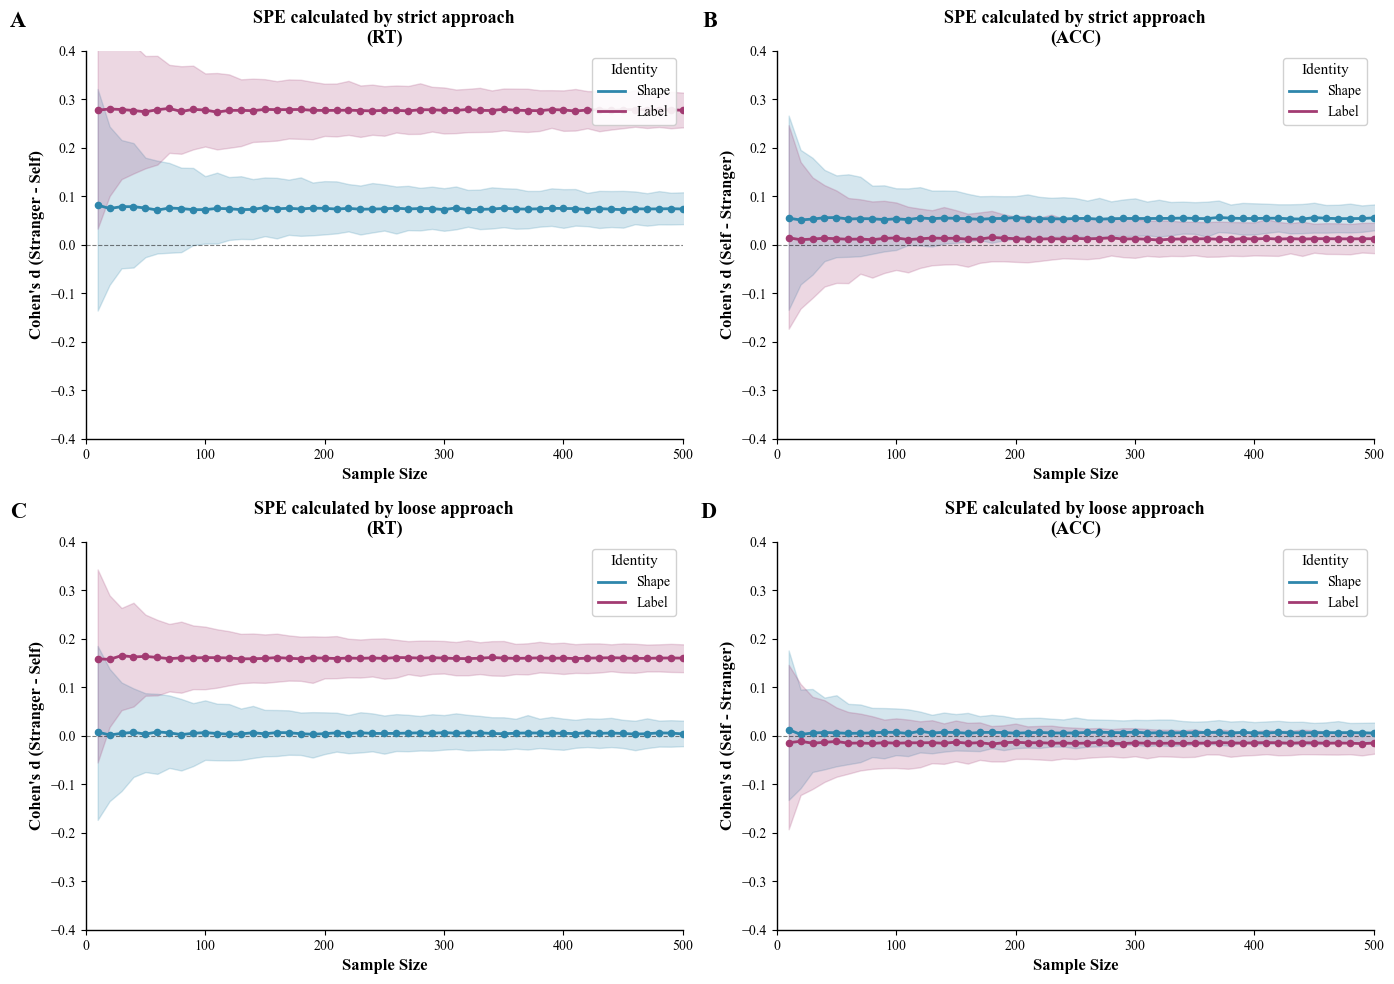

Saved: combined_figures_apa_original.png


In [13]:
# Generate Version 1: Original sample sizes
print("\n=== GENERATING VERSION 1: ORIGINAL SAMPLE SIZES ===")
create_apa_figure(rt_boot_strict, acc_boot_strict, rt_boot_loose, acc_boot_loose, version='original')


=== GENERATING VERSION 2: ALIGNED SAMPLE SIZES ===


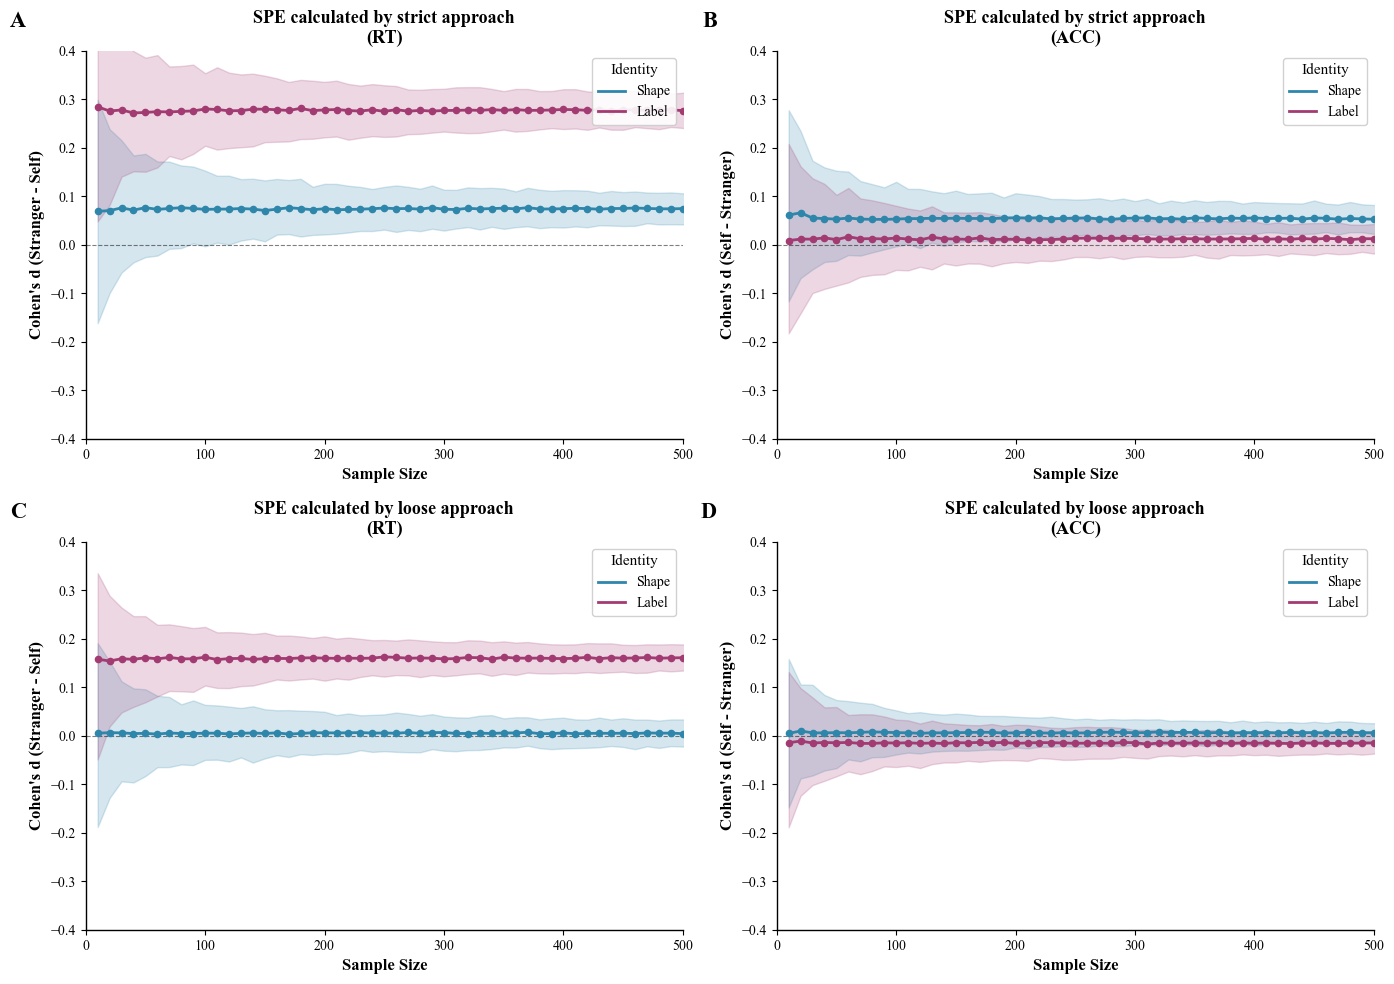

Saved: combined_figures_apa_aligned.png


In [14]:
# Generate Version 2: Aligned sample sizes
print("\n=== GENERATING VERSION 2: ALIGNED SAMPLE SIZES ===")
create_apa_figure(rt_boot_strict_aligned, acc_boot_strict_aligned, rt_boot_loose_aligned, acc_boot_loose_aligned, version='aligned')

In [15]:
# Save all results
print("\n=== SAVING RESULTS ===")

# Version 1: Original
rt_boot_strict.to_csv(output_path / 'bootstrap_rt_strict_original.csv', index=False)
acc_boot_strict.to_csv(output_path / 'bootstrap_acc_strict_original.csv', index=False)
rt_boot_loose.to_csv(output_path / 'bootstrap_rt_loose_original.csv', index=False)
acc_boot_loose.to_csv(output_path / 'bootstrap_acc_loose_original.csv', index=False)

# Version 2: Aligned
rt_boot_strict_aligned.to_csv(output_path / 'bootstrap_rt_strict_aligned.csv', index=False)
acc_boot_strict_aligned.to_csv(output_path / 'bootstrap_acc_strict_aligned.csv', index=False)
rt_boot_loose_aligned.to_csv(output_path / 'bootstrap_rt_loose_aligned.csv', index=False)
acc_boot_loose_aligned.to_csv(output_path / 'bootstrap_acc_loose_aligned.csv', index=False)

# Cohen's d by participant
all_cohens_d = []
for df, filtering, measure, identity in [
    (rt_shape_cohens_strict, 'Strict', 'RT', 'Shape'),
    (rt_label_cohens_strict, 'Strict', 'RT', 'Label'),
    (acc_shape_cohens_strict, 'Strict', 'ACC', 'Shape'),
    (acc_label_cohens_strict, 'Strict', 'ACC', 'Label'),
    (rt_shape_cohens_loose, 'Loose', 'RT', 'Shape'),
    (rt_label_cohens_loose, 'Loose', 'RT', 'Label'),
    (acc_shape_cohens_loose, 'Loose', 'ACC', 'Shape'),
    (acc_label_cohens_loose, 'Loose', 'ACC', 'Label'),
]:
    if not df.empty:
        df_copy = df.copy()
        df_copy['Filtering'] = filtering
        df_copy['Measure'] = measure
        df_copy['Identity'] = identity
        all_cohens_d.append(df_copy)

if all_cohens_d:
    pd.concat(all_cohens_d, ignore_index=True).to_csv(output_path / 'cohens_d_by_participant.csv', index=False)

print("All results saved!")


=== SAVING RESULTS ===
All results saved!


In [16]:
# Print summary
print("=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

for filtering, rt_boot, acc_boot in [('Strict', rt_boot_strict, acc_boot_strict), ('Loose', rt_boot_loose, acc_boot_loose)]:
    print(f"\n{filtering} Filtering:")
    for measure, boot_data in [('RT', rt_boot), ('ACC', acc_boot)]:
        if not boot_data.empty:
            print(f"  {measure}:")
            for identity in ['Shape', 'Label']:
                subset = boot_data[boot_data['Identity'] == identity]
                if not subset.empty:
                    final = subset.iloc[-1]
                    sig = "Yes" if (final['CI_lower'] > 0 or final['CI_upper'] < 0) else "No"
                    print(f"    {identity}: Mean d = {final['Mean_d']:.3f}, 95% CI [{final['CI_lower']:.3f}, {final['CI_upper']:.3f}], Significant: {sig}")

print("\n" + "=" * 80)
print("OUTPUT FILES:")
print("=" * 80)
print("\nFigures (300 dpi):")
print("  - combined_figures_apa_original.png (Version 1: original sample sizes)")
print("  - combined_figures_apa_aligned.png (Version 2: aligned sample sizes)")
print("\nData files:")
print("  - bootstrap_*_original.csv (Version 1 results)")
print("  - bootstrap_*_aligned.csv (Version 2 results)")
print("  - cohens_d_by_participant.csv (Individual Cohen's d values)")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)

ANALYSIS SUMMARY

Strict Filtering:
  RT:
    Shape: Mean d = 0.074, 95% CI [0.048, 0.098], Significant: Yes
    Label: Mean d = 0.277, 95% CI [0.245, 0.309], Significant: Yes
  ACC:
    Shape: Mean d = 0.054, 95% CI [0.033, 0.075], Significant: Yes
    Label: Mean d = 0.012, 95% CI [-0.017, 0.041], Significant: No

Loose Filtering:
  RT:
    Shape: Mean d = 0.006, 95% CI [-0.014, 0.026], Significant: No
    Label: Mean d = 0.160, 95% CI [0.140, 0.179], Significant: Yes
  ACC:
    Shape: Mean d = 0.006, 95% CI [-0.010, 0.021], Significant: No
    Label: Mean d = -0.015, 95% CI [-0.033, 0.002], Significant: No

OUTPUT FILES:

Figures (300 dpi):
  - combined_figures_apa_original.png (Version 1: original sample sizes)
  - combined_figures_apa_aligned.png (Version 2: aligned sample sizes)

Data files:
  - bootstrap_*_original.csv (Version 1 results)
  - bootstrap_*_aligned.csv (Version 2 results)
  - cohens_d_by_participant.csv (Individual Cohen's d values)

ANALYSIS COMPLETE!


## Summary of Changes (v3)

### Figure Titles
- Row 1: "SPE calculated by strict approach"
- Row 2: "SPE calculated by loose approach"

### APA Style
- No grid lines
- White background
- Fixed axes: X [0, 500], Y [-0.4, 0.4]
- Times New Roman font
- Subplot labels (A, B, C, D)

### Two Versions

**Version 1: Original**
- Sample sizes as calculated
- Shape and Label may have different max sample sizes

**Version 2: Aligned**
- Sample sizes limited to min(Shape, Label)
- Both lines end at the same sample size
- Easier comparison between Shape and Label